# PCA
Principal Component Analysis transforms your data into a new coordinate system such that:
The first principal component captures the maximum variance.
The second principal component captures the next highest variance, orthogonal to the first.
And so on...

This helps:
Reduce dimensionality (fewer variables)
Visualize high-dimensional data (e.g., in 2D)
Remove multicollinearity
Improve model performance (sometimes)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.decomposition import PCA as sklearnPCA

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'

data = pd.read_csv(url, header=None)

data.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
y = data[4]

y[0:5]

y.unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [4]:
X = data.iloc[:,0:4]

X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
X[y=='Iris-setosa'].head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


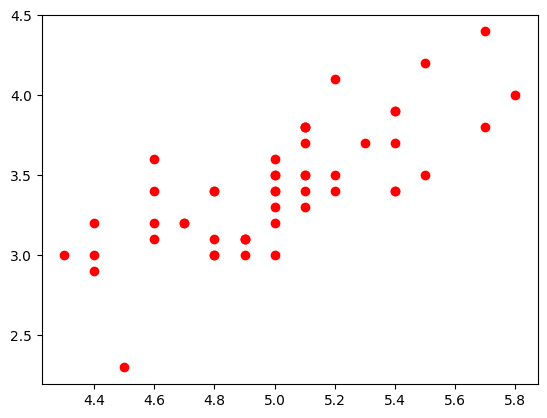

In [6]:
plt.scatter(X[y=='Iris-setosa'].iloc[:,0], X[y=='Iris-setosa'].iloc[:,1], label='Iris-setosa', c='red')

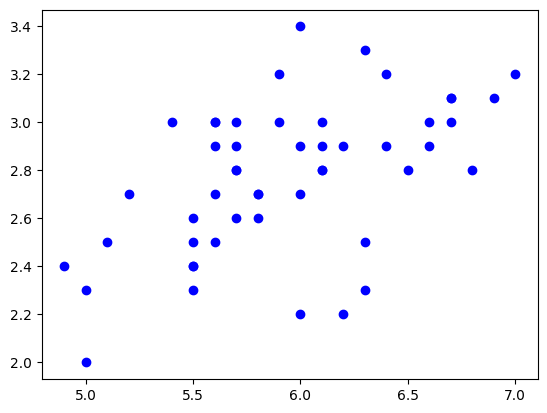

In [7]:
plt.scatter(X[y=='Iris-versicolor'].iloc[:,0], X[y=='Iris-versicolor'].iloc[:,1], label='Iris-versicolor', c='blue')

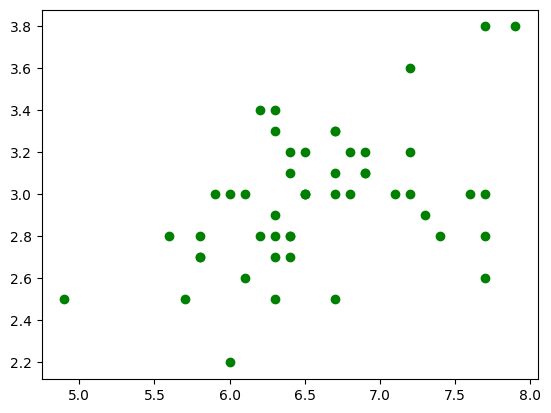

In [8]:
plt.scatter(X[y=='Iris-virginica'].iloc[:,0], X[y=='Iris-virginica'].iloc[:,1], label='Iris-virginica', c='green')

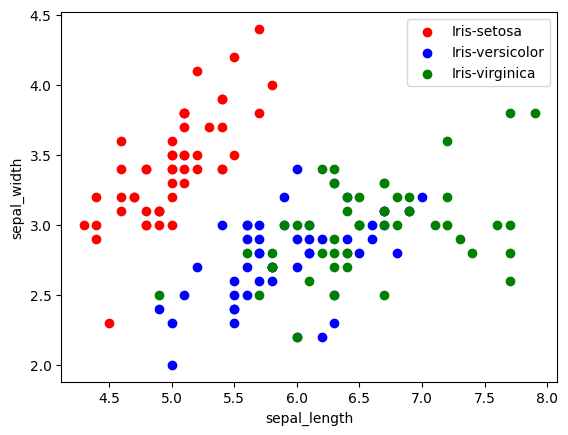

In [9]:
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')

plt.scatter(X[y=='Iris-setosa'].iloc[:,0], X[y=='Iris-setosa'].iloc[:,1], label='Iris-setosa', c='red')
plt.scatter(X[y=='Iris-versicolor'].iloc[:,0], X[y=='Iris-versicolor'].iloc[:,1], label='Iris-versicolor', c='blue')
plt.scatter(X[y=='Iris-virginica'].iloc[:,0], X[y=='Iris-virginica'].iloc[:,1], label='Iris-virginica', c='green')


plt.legend()

plt.show()

In [10]:
X

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [11]:
X_norm = (X - X.min()) / (X.max()-X.min())

In [17]:
X_norm

,0,1,2,3
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667
...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667
146,0.555556,0.208333,0.677966,0.750000
147,0.611111,0.416667,0.711864,0.791667
148,0.527778,0.583333,0.745763,0.916667


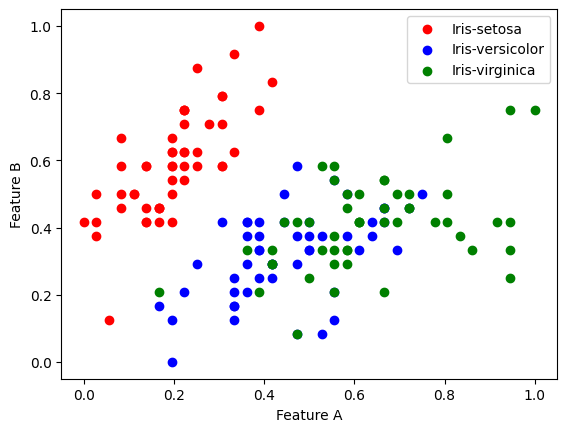

In [13]:
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')

plt.scatter(X_norm[y=='Iris-setosa'].iloc[:,0], X_norm[y=='Iris-setosa'].iloc[:,1], label='Iris-setosa', c='red')
plt.scatter(X_norm[y=='Iris-versicolor'].iloc[:,0], X_norm[y=='Iris-versicolor'].iloc[:,1], label='Iris-versicolor', c='blue')
plt.scatter(X_norm[y=='Iris-virginica'].iloc[:,0], X_norm[y=='Iris-virginica'].iloc[:,1], label='Iris-virginica', c='green')

plt.legend()
plt.xlabel('Feature A')
plt.ylabel('Feature B')

plt.show()

In [14]:
pca = sklearnPCA(n_components=2)

In [15]:
transformed = pd.DataFrame(pca.fit_transform(X_norm))

print(X_norm.head())
print(transformed.head())

          0         1         2         3
0  0.222222  0.625000  0.067797  0.041667
1  0.166667  0.416667  0.067797  0.041667
2  0.111111  0.500000  0.050847  0.041667
3  0.083333  0.458333  0.084746  0.041667
4  0.194444  0.666667  0.067797  0.041667
          0         1
0 -0.630361  0.111556
1 -0.623546 -0.100313
2 -0.669793 -0.047220
3 -0.654633 -0.098791
4 -0.648263  0.137558


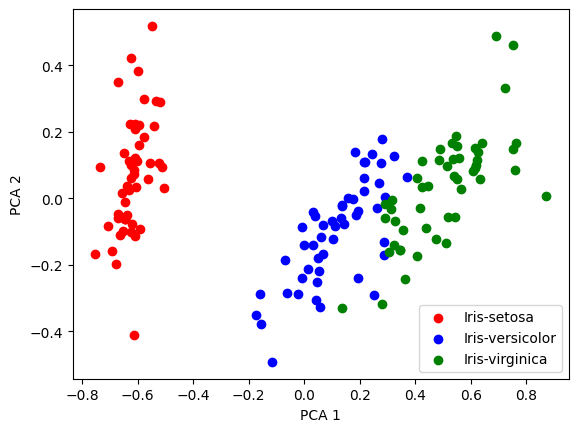

In [18]:
plt.scatter(transformed[y=='Iris-setosa'].iloc[:,0], transformed[y=='Iris-setosa'].iloc[:,1], label='Iris-setosa', c='red')
plt.scatter(transformed[y=='Iris-versicolor'].iloc[:,0], transformed[y=='Iris-versicolor'].iloc[:,1], label='Iris-versicolor', c='blue')
plt.scatter(transformed[y=='Iris-virginica'].iloc[:,0], transformed[y=='Iris-virginica'].iloc[:,1], label='Iris-virginica', c='green')

plt.legend()
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.show()